This project performs an end-to-end Exploratory Data Analysis (EDA) on a mental health survey dataset, focusing on data cleaning, outlier handling, and deriving actionable business insights.

Author - Shashank Aman

Date - 2 May 2026

# Import Required Libraries

In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load Dataset

In [134]:
# Load the dataset
df = pd.read_csv("/content/survey.csv")

# Dataset Overview
Shape, info, describe

In [135]:
df

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN


In [136]:
df.shape

(1259, 27)

In [137]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


# DATA CLEANING

Standardizing Gender Values into Male, Female, Other

In [138]:
# Clean gender values
df['Gender'] = df['Gender'].str.strip().str.lower().replace({
    # Male
    'male': 'Male', 'm': 'Male', 'man': 'Male',
    'cis male': 'Male', 'cis man': 'Male',
    'male (cis)': 'Male', 'male-ish': 'Male',
    'mal': 'Male', 'malr': 'Male', 'maile': 'Male',
    'make': 'Male', 'mail': 'Male', 'msle': 'Male',
    'guy': 'Male', 'guy (-ish) ^_^': 'Male',
    'male leaning androgynous': 'Male',
    'ostensibly male': 'Male',

    # Female
    'female': 'Female', 'f': 'Female', 'woman': 'Female',
    'cis female': 'Female', 'female (cis)': 'Female',
    'cis-female/femme': 'Female',
    'femake': 'Female', 'femail': 'Female',

    # Other (direct mapping)
    'non-binary': 'Other', 'trans-female': 'Other',
    'trans female': 'Other', 'trans woman': 'Other',
    'trans male': 'Other', 'genderfluid': 'Other',
    'agender': 'Other', 'neuter': 'Other',
    'androgynous': 'Other', 'queer': 'Other',
    'enby': 'Other', 'fluid': 'Other',
    'genderqueer': 'Other', 'androgyne': 'Other',
    'queer/she/they': 'Other',

    # Garbage / unclear
    'nah': 'Other', 'all': 'Other',
    'a little about you': 'Other', 'p': 'Other'
})

# Extra safety (If any type is missed)
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Male', 'Female'] else 'Other')


# Age Cleaning

Convert Age to numeric and handle invalid values

Force Age Column to Numeric

In [139]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

Remove Unrealistic Values

In [140]:
df['Age'] = df['Age'].apply(lambda x: x if 15 <= x <= 70 else np.nan)

Drop Nulls

In [141]:
df = df.dropna(subset=['Age'])

# OUTLIER ANALYSIS

Visualizing Age Distribution using Boxplot

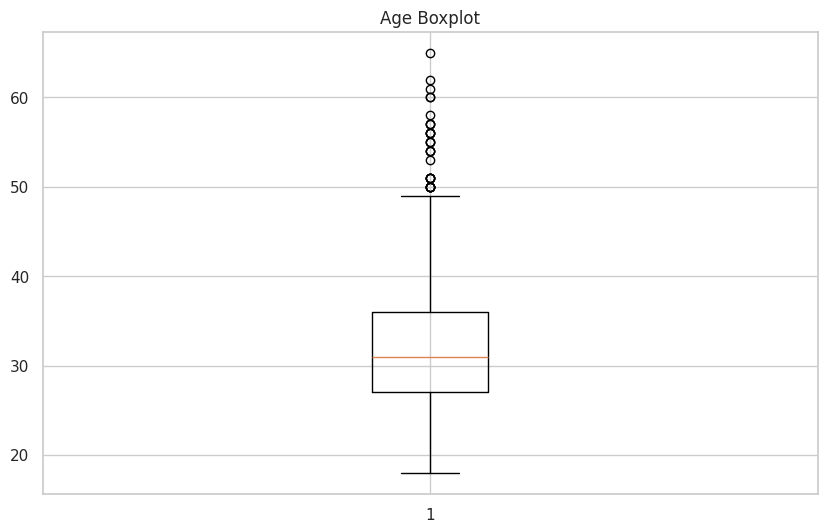

In [142]:
plt.boxplot(df['Age'])
plt.title("Age Boxplot")
plt.show()

# EXPLORATORY DATA ANALYSIS (EDA)

Age Distribution

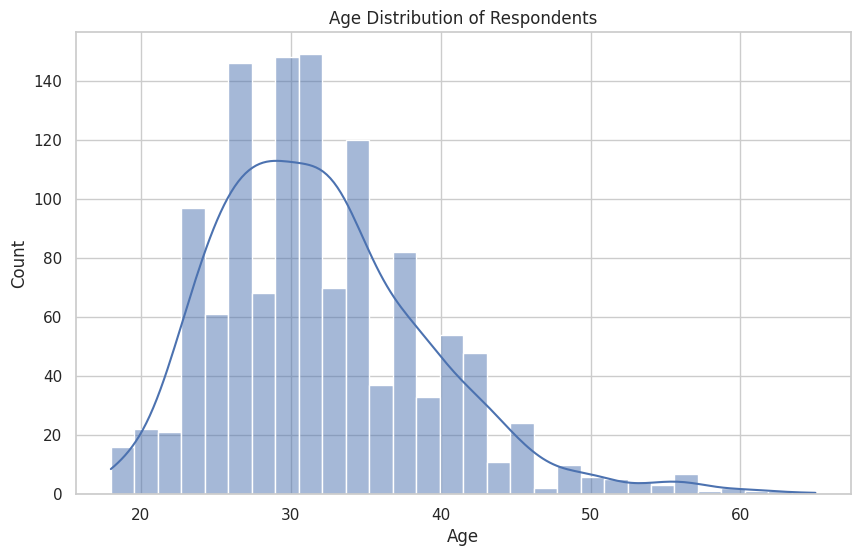

In [143]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution of Respondents")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Most respondents fall in the 25–35 age range, indicating a young working population.

Gender Distribution

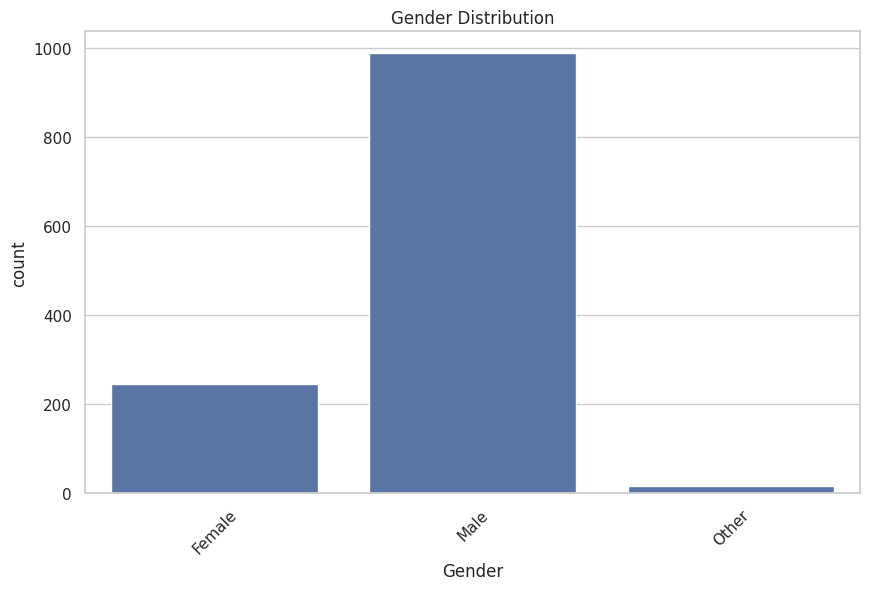

In [144]:
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()


Majority of respondents are Male, with relatively fewer Female and Other participants.

Top 10 Countries by Distribution

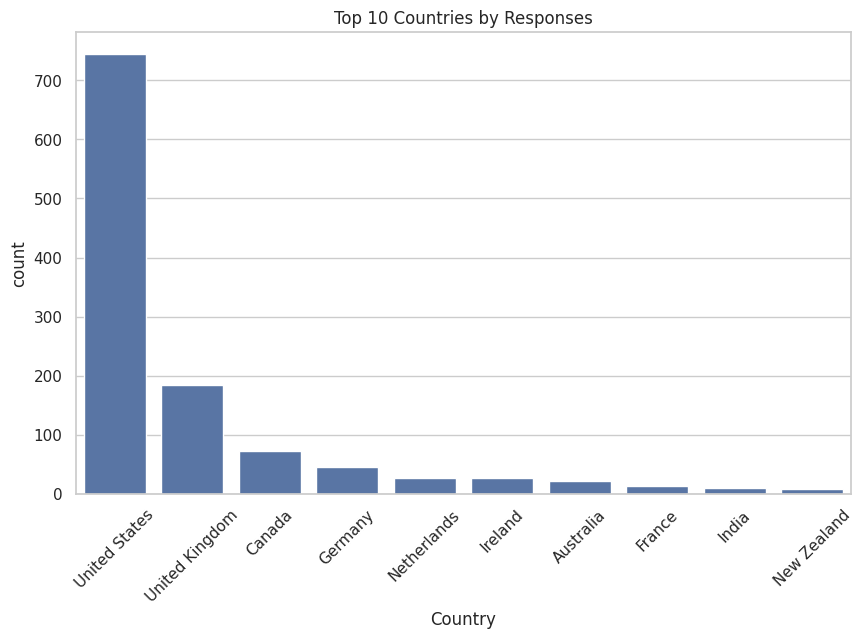

In [145]:
top_countries = df['Country'].value_counts().head(10).index
sns.countplot(data=df[df['Country'].isin(top_countries)], x="Country", order=top_countries)
plt.title("Top 10 Countries by Responses")
plt.xticks(rotation=45)
plt.show()


Most responses are concentrated in a few countries, with the highest participation coming from developed tech-driven regions. This indicates that the dataset is skewed towards certain geographic locations.

Treatment Count

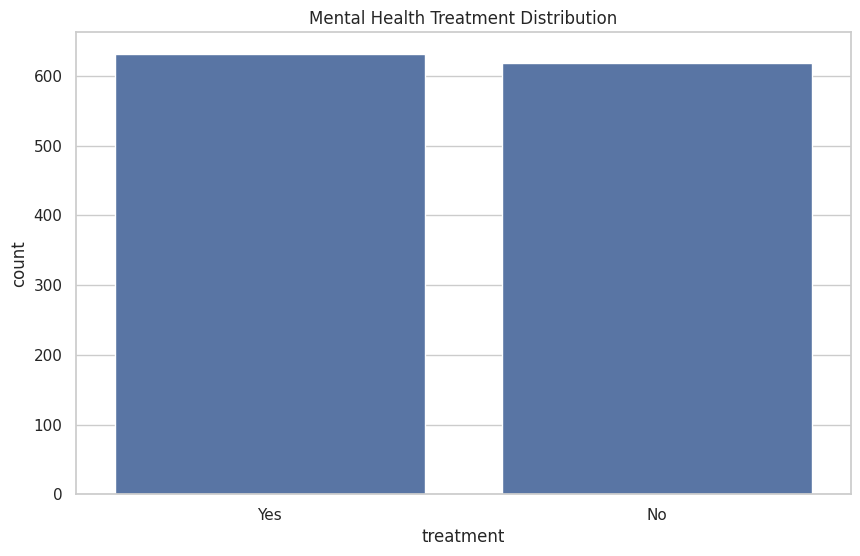

In [146]:
sns.countplot(data=df, x="treatment")
plt.title("Mental Health Treatment Distribution")
plt.show()


A significant portion of respondents have sought mental health treatment, highlighting growing awareness.

Family History vs Treatment

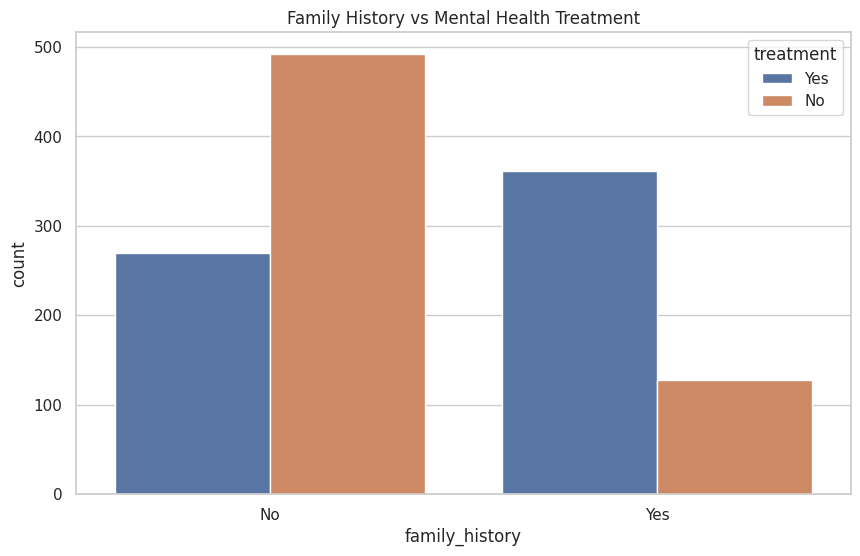

In [147]:
sns.countplot(data=df, x="family_history", hue="treatment")
plt.title("Family History vs Mental Health Treatment")
plt.show()


Individuals with a family history of mental illness are more likely to seek treatment.

Remote Work vs Treatment

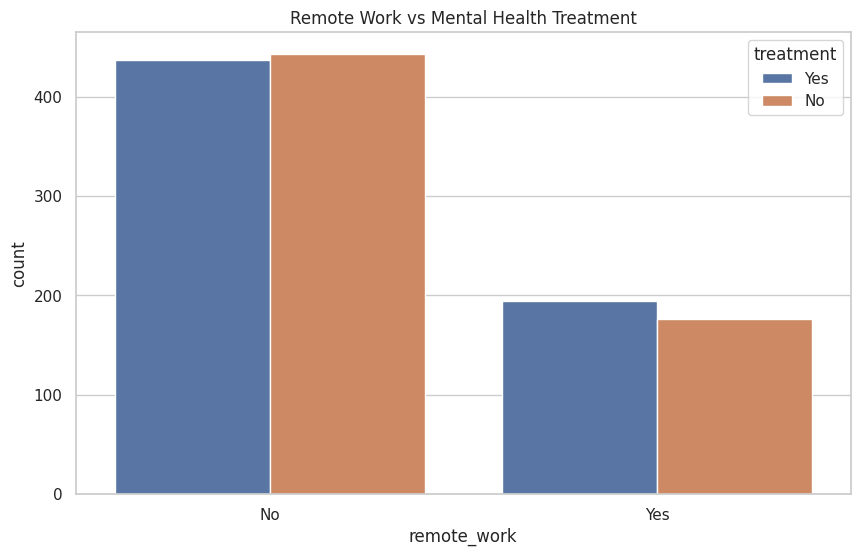

In [148]:
sns.countplot(data=df, x="remote_work", hue="treatment")
plt.title("Remote Work vs Mental Health Treatment")
plt.show()


Remote work does not show a strong direct impact on treatment-seeking behavior.

Work Interference Distribution

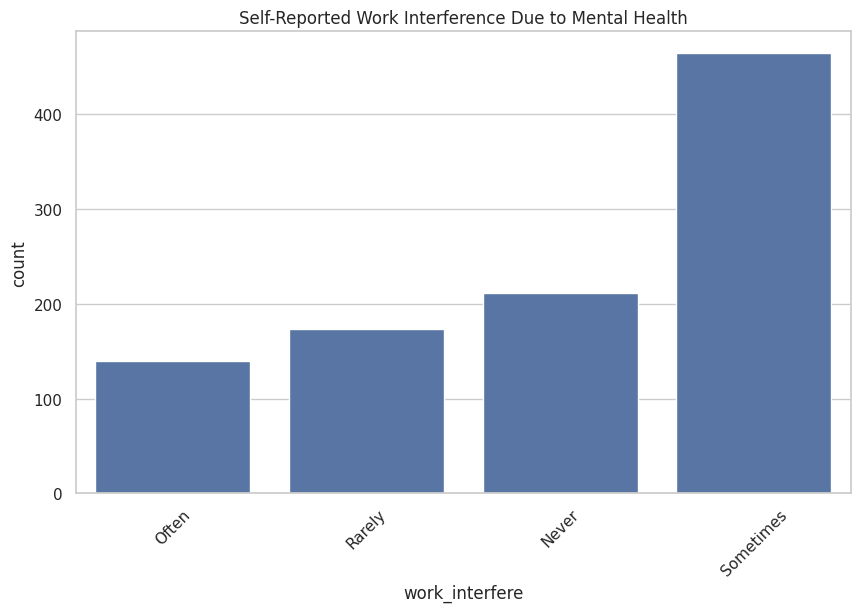

In [149]:
sns.countplot(data=df, x="work_interfere")
plt.title("Self-Reported Work Interference Due to Mental Health")
plt.xticks(rotation=45)
plt.show()


Many respondents report that mental health issues interfere with their work, affecting productivity.

Company Size vs Treatment

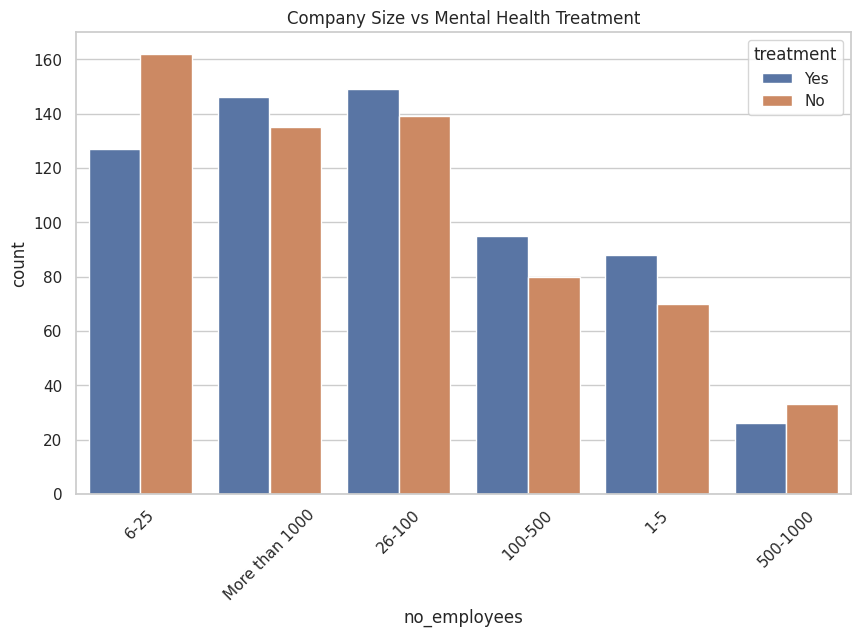

In [150]:
sns.countplot(data=df, x="no_employees", hue="treatment")
plt.title("Company Size vs Mental Health Treatment")
plt.xticks(rotation=45)
plt.show()


Employees in larger organizations appear more likely to seek treatment, possibly due to better support systems.

Benefits Available

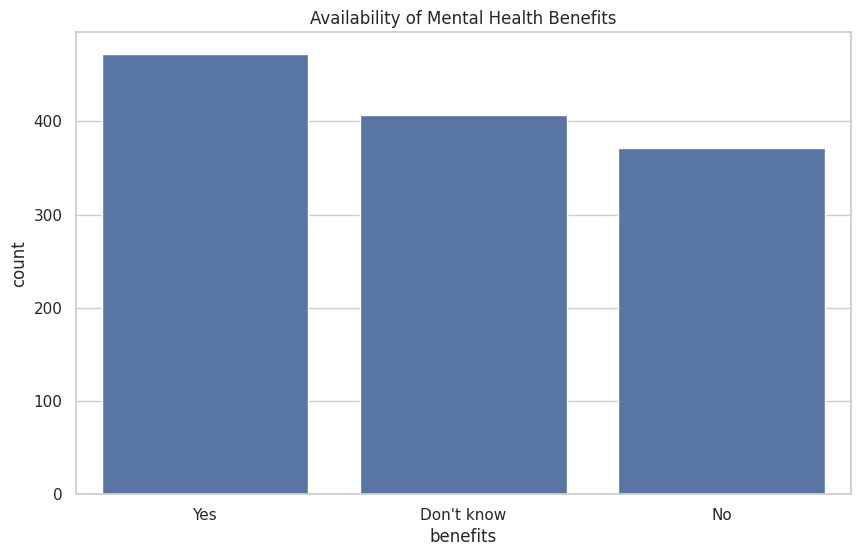

In [151]:
sns.countplot(data=df, x="benefits")
plt.title("Availability of Mental Health Benefits")
plt.show()


Not all companies provide mental health benefits, indicating a gap in workplace support.

Care Options vs Treatment

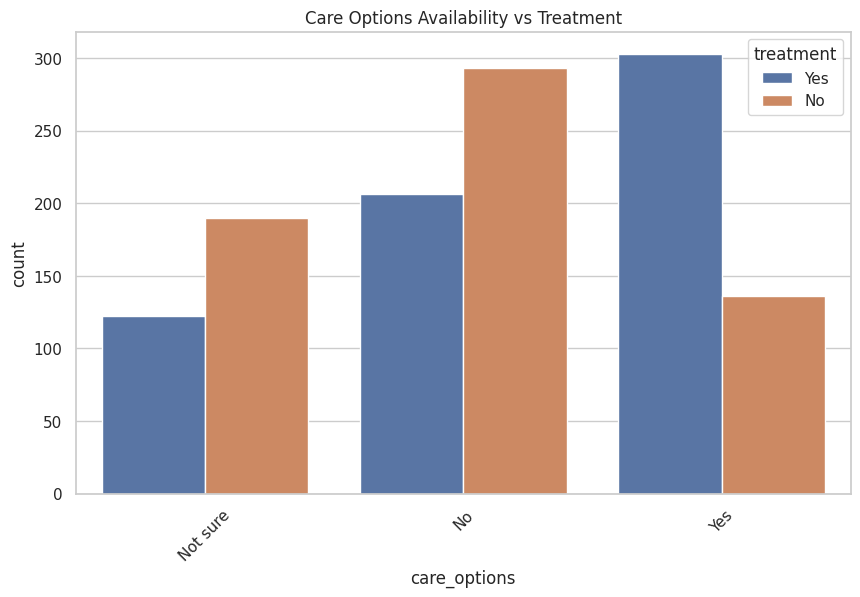

In [152]:
sns.countplot(data=df, x="care_options", hue="treatment")
plt.title("Care Options Availability vs Treatment")
plt.xticks(rotation=45)
plt.show()


Individuals who have access to mental health care options are more likely to seek treatment, highlighting the importance of organizational support systems.

Wellness Program Availability

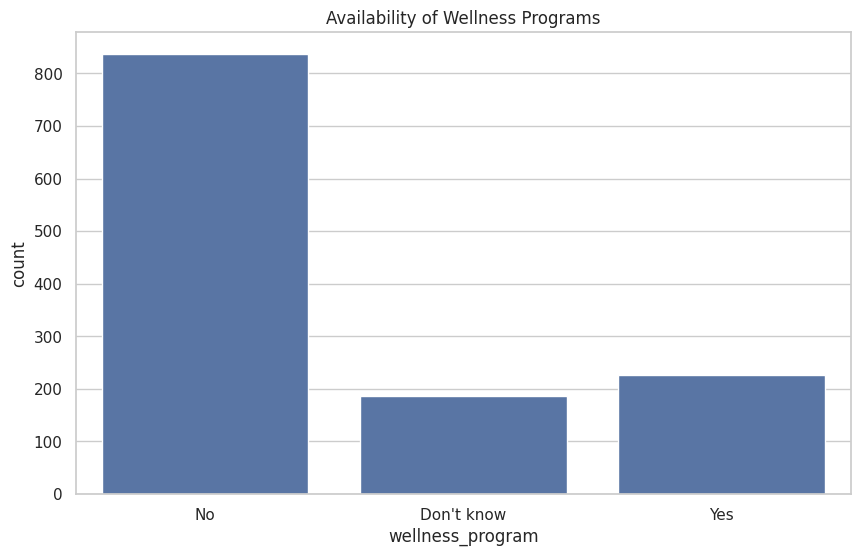

In [153]:
sns.countplot(data=df, x="wellness_program")
plt.title("Availability of Wellness Programs")
plt.show()


A significant number of respondents reported lack of wellness programs, suggesting that many organizations still do not actively promote mental health initiatives.

Seeking Help Awareness

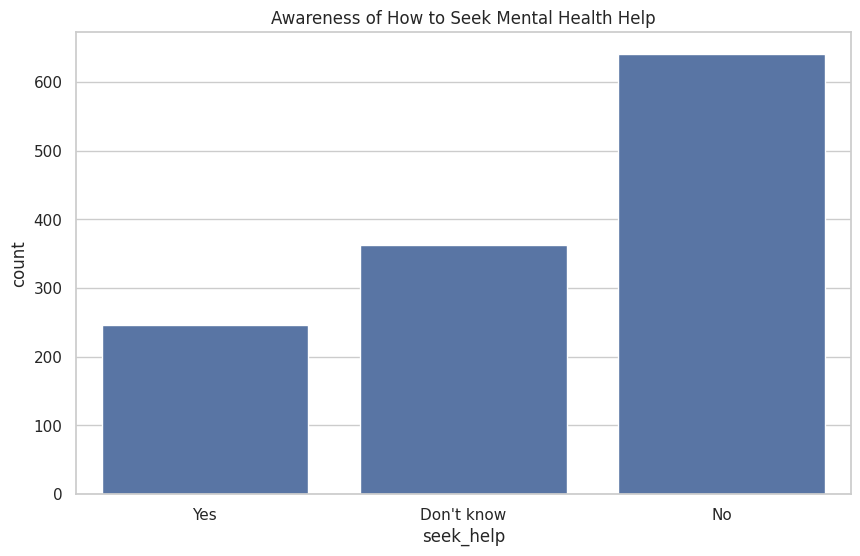

In [154]:
sns.countplot(data=df, x="seek_help")
plt.title("Awareness of How to Seek Mental Health Help")
plt.show()


Awareness about how to seek mental health help varies across respondents, indicating gaps in communication and support within organizations.

Anonymity vs Treatment

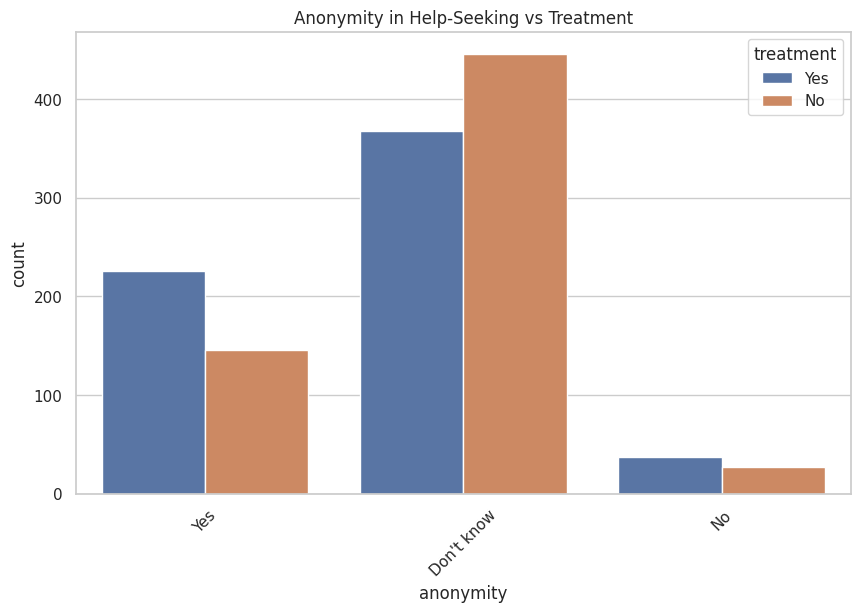

In [155]:
sns.countplot(data=df, x="anonymity", hue="treatment")
plt.title("Anonymity in Help-Seeking vs Treatment")
plt.xticks(rotation=45)
plt.show()


Availability of anonymity may encourage individuals to seek treatment, as privacy concerns often influence mental health decisions.

Mental vs Physical Health Preception

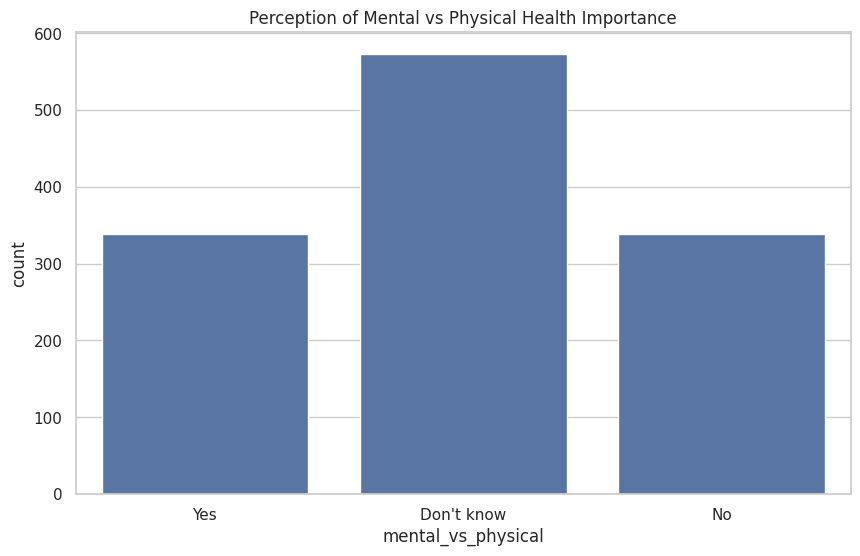

In [156]:
sns.countplot(data=df, x="mental_vs_physical")
plt.title("Perception of Mental vs Physical Health Importance")
plt.show()


Many respondents perceive mental health as equally important as physical health, though some still undervalue its significance.

Leave Ease vs Treatment

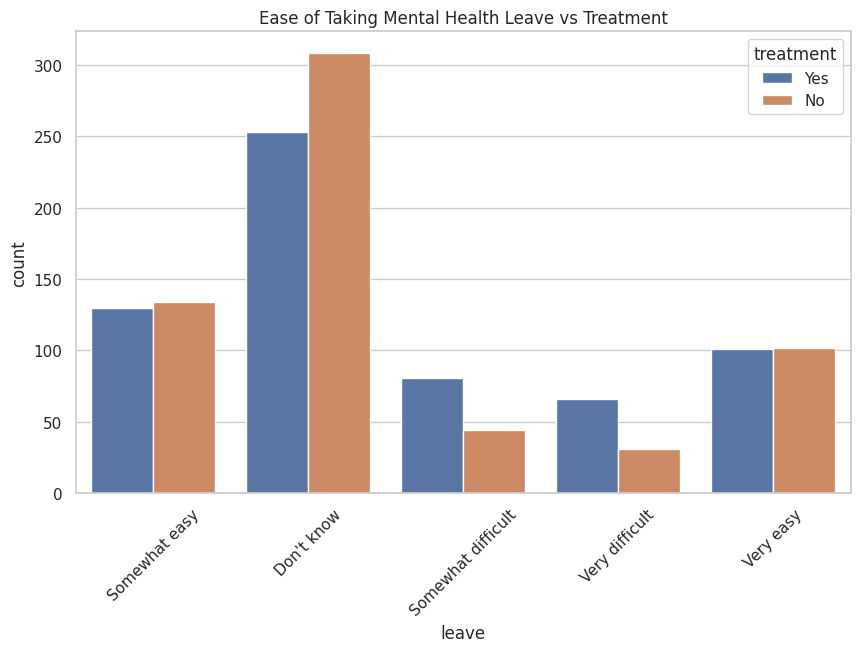

In [157]:
sns.countplot(data=df, x="leave", hue="treatment")
plt.title("Ease of Taking Mental Health Leave vs Treatment")
plt.xticks(rotation=45)
plt.show()


Ease of taking leave for mental health varies significantly, which can impact an employee’s willingness to seek treatment.

Observale Consequences at Work

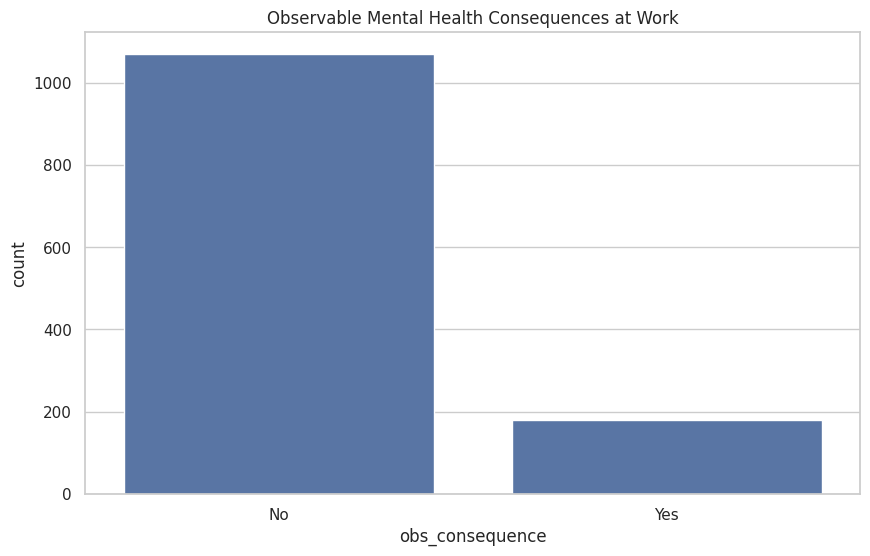

In [158]:
sns.countplot(data=df, x="obs_consequence")
plt.title("Observable Mental Health Consequences at Work")
plt.show()


Observable mental health consequences at the workplace are reported by several respondents, indicating the visible impact of mental health issues on work environments.

# RELATIONSHIP ANALYSIS

In [159]:
# Treatment % by Gender
gender_treatment = pd.crosstab(df['Gender'], df['treatment'], normalize='index') * 100
print(gender_treatment)

# Family history impact
family_treatment = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
print(family_treatment)

# Work interference impact
work_treatment = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100
print(work_treatment)

treatment         No        Yes
Gender                         
Female     31.300813  68.699187
Male       54.554656  45.445344
Other      18.750000  81.250000
treatment              No        Yes
family_history                      
No              64.566929  35.433071
Yes             26.024590  73.975410
treatment              No        Yes
work_interfere                      
Never           86.255924  13.744076
Often           15.000000  85.000000
Rarely          29.479769  70.520231
Sometimes       23.060345  76.939655


Relationship analysis shows that individuals with a family history of mental illness and those experiencing work interference are significantly more likely to seek treatment. This highlights key factors influencing mental health behavior.

#Insights

* Individuals with family history have significantly higher treatment rates
* Work interference strongly correlates with mental health treatment
* Gender differences in treatment behavior are minimal but present

# Key Findings

* Majority of respondents are aged 25–35, representing a young workforce
* Mental health issues significantly impact work productivity
* Individuals with a family history of mental illness are more likely to seek treatment
* Many companies lack proper mental health benefits and wellness programs
* Awareness about seeking help exists but is still inconsistent

# Business Implications

* Organizations need to invest in mental health support systems
* Awareness programs should be improved across companies
* Flexible work policies alone are not enough — structured support is required

# RECOMMENDATIONS

- Implement company-wide mental health awareness programs
- Provide accessible and confidential mental health support
- Encourage open conversations to reduce stigma
- Improve availability of wellness programs

# LIMITATIONS

- Dataset is survey-based, so responses may include bias
- Majority responses are from tech industry
- Self-reported data may not always be accurate